# Chapter 145 — Vectors in Machine Learning

> **Prerequisites:** ch131 (Dot Product), ch128 (Norm), ch129 (Distance), ch133 (Angles), ch134 (Projections), ch127 (Linear Combination)  
> **You will learn:**
> - How data points, feature vectors, and model parameters are all vectors
> - How similarity, distance, and angle between vectors power core ML algorithms
> - How a linear model is a dot product; how a neuron is a dot product + nonlinearity
> - How vector arithmetic on embeddings encodes semantic meaning
> - How the geometry of high-dimensional vector spaces shapes ML behavior
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

In machine learning, virtually everything is a vector:

- A **data point** is a vector of feature values: **x** = (age, income, height, ...) ∈ ℝⁿ
- A **model parameter set** is a vector: **w** ∈ ℝⁿ (weights), b ∈ ℝ (bias)
- A **word embedding** is a vector: "king" → **e** ∈ ℝ³⁰⁰
- A **neural network layer** is a linear transformation of its input vector
- **Predictions** are dot products: ŷ = **w** · **x** + b
- **Loss gradients** are vectors pointing in the direction of steepest parameter change

Every operation in ML reduces to vector operations: addition, scalar multiplication, dot products, norms, and matrix-vector products. Understanding vectors is not background — it is the core.

**Common misconception:** "Feature engineering is domain-specific; vectors are just storage." Wrong — the geometric relationships between feature vectors (distance, angle, projection) determine what the model can and cannot learn.

---

## 2. Intuition & Mental Models

**Data as points in space:** Each data sample is a point in n-dimensional feature space. Classification draws boundaries between clusters of points. Regression finds a hyperplane passing through the cloud. The geometry of the cloud determines difficulty.

**Prediction as dot product:** A linear model computes ŷ = **w** · **x**. Geometrically, this is the projection of **x** onto **w**, scaled by ‖**w**‖. The sign of the dot product determines which side of the decision boundary **x** falls on. *(Projection, introduced in ch134.)*

**Cosine similarity:** Two feature vectors with small angle between them (large cosine similarity) represent similar samples. This is more robust than Euclidean distance in high dimensions because it ignores magnitude — a common technique in text and recommendation systems. *(Angles, introduced in ch133.)*

**Embedding arithmetic:** In word2vec-style embeddings, semantic relationships are encoded as vector differences: **e**(king) − **e**(man) ≈ **e**(queen) − **e**(woman). Addition and subtraction on embedding vectors correspond to semantic composition.

---

## 3. Visualization

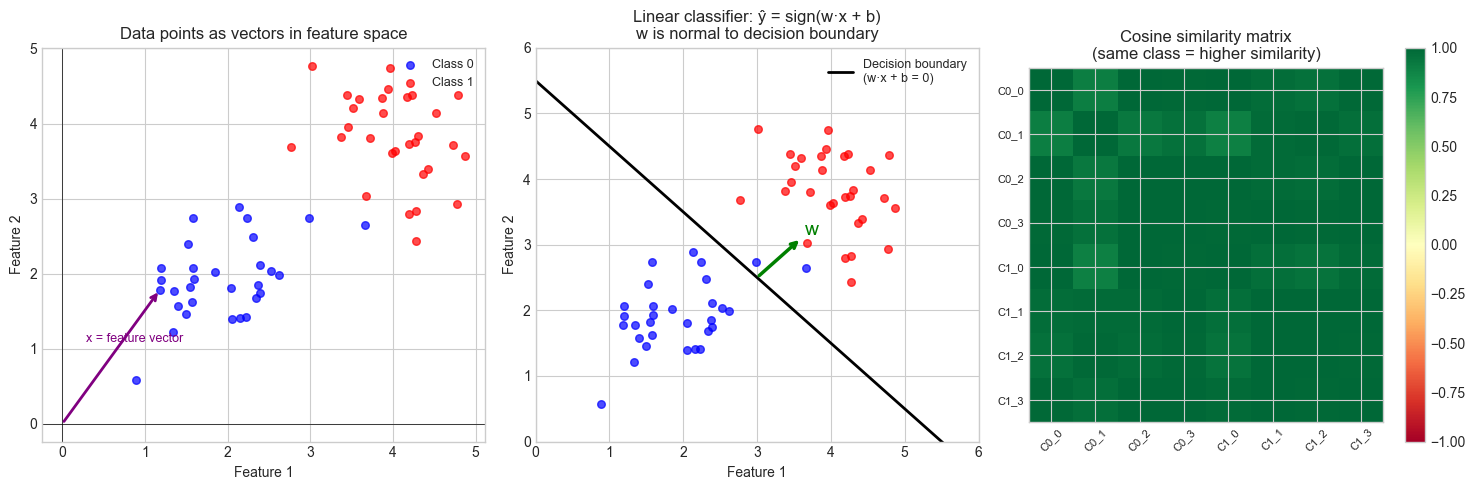

In [1]:
# --- Visualization: Feature space geometry and linear classification ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: Data as vectors in feature space ---
ax = axes[0]
# Two classes
class0 = rng.multivariate_normal([2,2], [[0.5,0.2],[0.2,0.5]], 30)
class1 = rng.multivariate_normal([4,4], [[0.5,-0.1],[-0.1,0.5]], 30)
ax.scatter(*class0.T, c='blue', s=30, label='Class 0', alpha=0.7)
ax.scatter(*class1.T, c='red', s=30, label='Class 1', alpha=0.7)
# Show one sample as a vector from origin
sample = class0[5]
ax.annotate('', xy=sample, xytext=[0,0],
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))
ax.text(sample[0]/2-0.3, sample[1]/2+0.2, 'x = feature vector', fontsize=9, color='purple')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title('Data points as vectors in feature space')
ax.legend(fontsize=9)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

# --- Panel 2: Linear classifier as dot product ---
ax2 = axes[1]
# Weight vector defines the normal to the decision boundary
w = np.array([1.0, 1.0])  # weight vector
b = -5.5                   # bias

ax2.scatter(*class0.T, c='blue', s=30, alpha=0.7)
ax2.scatter(*class1.T, c='red', s=30, alpha=0.7)

# Decision boundary: w·x + b = 0  =>  x2 = -(w1*x1 + b)/w2
x1_vals = np.linspace(0, 6, 100)
x2_boundary = -(w[0]*x1_vals + b) / w[1]
ax2.plot(x1_vals, x2_boundary, 'k-', lw=2, label='Decision boundary\n(w·x + b = 0)')

# Weight vector (normal to boundary)
mid = np.array([3.0, -(w[0]*3.0+b)/w[1]])
ax2.annotate('', xy=mid+w*0.6, xytext=mid,
             arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax2.text(mid[0]+w[0]*0.65, mid[1]+w[1]*0.65, 'w', fontsize=14, color='green')
ax2.set_xlim(0, 6); ax2.set_ylim(0, 6)
ax2.set_xlabel('Feature 1'); ax2.set_ylabel('Feature 2')
ax2.set_title('Linear classifier: ŷ = sign(w·x + b)\nw is normal to decision boundary')
ax2.legend(fontsize=9)

# --- Panel 3: Cosine similarity heatmap ---
ax3 = axes[2]
# Sample 8 data points and compute pairwise cosine similarity
pts = np.vstack([class0[:4], class1[:4]])
norms = np.linalg.norm(pts, axis=1, keepdims=True)
pts_normed = pts / norms
cos_sim = pts_normed @ pts_normed.T

im = ax3.imshow(cos_sim, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax3)
ax3.set_xticks(range(8))
ax3.set_yticks(range(8))
labels = [f'C0_{i}' for i in range(4)] + [f'C1_{i}' for i in range(4)]
ax3.set_xticklabels(labels, fontsize=8, rotation=45)
ax3.set_yticklabels(labels, fontsize=8)
ax3.set_title('Cosine similarity matrix\n(same class = higher similarity)')

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Linear model (regression):**
```
ŷ = w · x + b = wᵀx + b
```
where **w** ∈ ℝⁿ (weights), b ∈ ℝ (bias), **x** ∈ ℝⁿ (features).
This is a dot product — the projection of **x** onto **w**, scaled and shifted.

**Linear classifier:**
```
ŷ = sign(w · x + b)
```
The decision boundary is the hyperplane {**x** : **w** · **x** + b = 0}. The weight vector **w** is normal to this hyperplane.

**Neuron (single):**
```
output = σ(w · x + b)
```
where σ is a non-linear activation function (sigmoid, ReLU, etc.).
The linear part is a dot product; the non-linearity is applied after.

**Cosine similarity:**
```
cos_sim(x, y) = (x · y) / (||x|| · ||y||) ∈ [−1, 1]
```
Used in: nearest-neighbor search, recommendation systems, NLP similarity.

**k-NN distance:**
```
distance(x, xᵢ) = ||x - xᵢ||₂
```
The k nearest neighbors are the k training points with smallest distance to **x**.

**Embedding arithmetic (word2vec):**
```
e(king) - e(man) + e(woman) ≈ e(queen)
```
Semantic relationships = vector arithmetic in embedding space.

**Batch prediction (matrix form):**
```
ŷ = Xw + b
```
where X is the data matrix (N samples × n features). This is a matrix-vector product, covered in ch151+.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Core ML vector operations from scratch ---

import numpy as np


def cosine_similarity(a, b):
    """
    Cosine similarity between vectors a and b.
    Returns scalar in [-1, 1].
    """
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


def cosine_similarity_matrix(X):
    """
    Pairwise cosine similarity for all rows of X.

    Args:
        X: np.ndarray, shape (N, d)

    Returns:
        np.ndarray, shape (N, N)
    """
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_normed = X / (norms + 1e-12)
    return X_normed @ X_normed.T


def linear_predict(X, w, b):
    """
    Linear model prediction: ŷ = Xw + b

    Args:
        X: np.ndarray, shape (N, d)
        w: np.ndarray, shape (d,)
        b: float

    Returns:
        np.ndarray, shape (N,)
    """
    return X @ w + b


def knn_predict(X_train, y_train, X_test, k=3):
    """
    k-nearest neighbors classifier using Euclidean distance.

    Args:
        X_train: np.ndarray, shape (N, d)
        y_train: np.ndarray, shape (N,)  — integer class labels
        X_test:  np.ndarray, shape (M, d)
        k: int — number of neighbors

    Returns:
        np.ndarray, shape (M,) — predicted class labels
    """
    predictions = []
    for x in X_test:
        # Distance from x to each training point
        diffs = X_train - x            # shape (N, d)
        dists = np.linalg.norm(diffs, axis=1)  # shape (N,)
        knn_idx = np.argsort(dists)[:k]
        # Majority vote
        neighbor_labels = y_train[knn_idx]
        pred = np.bincount(neighbor_labels).argmax()
        predictions.append(pred)
    return np.array(predictions)


def sigmoid(z):
    """Sigmoid activation: σ(z) = 1 / (1 + e^{-z})"""
    return 1.0 / (1.0 + np.exp(-z))


# --- Demo: kNN on synthetic 2D data ---
rng = np.random.default_rng(0)
X_train = np.vstack([
    rng.multivariate_normal([1,1], 0.3*np.eye(2), 30),
    rng.multivariate_normal([3,3], 0.3*np.eye(2), 30),
])
y_train = np.array([0]*30 + [1]*30)

X_test = np.array([[2., 2.], [0.5, 1.2], [3.5, 3.5], [1.5, 2.5]])
preds = knn_predict(X_train, y_train, X_test, k=5)

print("k-NN predictions (k=5):")
for x, p in zip(X_test, preds):
    print(f"  x={x}  ->  class {p}")

print()
print("Cosine similarities between test points:")
C = cosine_similarity_matrix(X_test)
print(C.round(3))

k-NN predictions (k=5):
  x=[2. 2.]  ->  class 0
  x=[0.5 1.2]  ->  class 0
  x=[3.5 3.5]  ->  class 1
  x=[1.5 2.5]  ->  class 0

Cosine similarities between test points:
[[1.    0.925 1.    0.97 ]
 [0.925 1.    0.925 0.989]
 [1.    0.925 1.    0.97 ]
 [0.97  0.989 0.97  1.   ]]


In [3]:
# --- Embedding arithmetic demo ---
# Simulate word2vec-style embeddings with synthetic vectors

import numpy as np

rng = np.random.default_rng(7)
DIM = 50  # embedding dimension  <-- try 5, 300

# Construct embeddings with built-in analogies
# Gender axis: man-woman, king-queen
gender_axis = rng.standard_normal(DIM)
gender_axis /= np.linalg.norm(gender_axis)

royalty_axis = rng.standard_normal(DIM)
royalty_axis /= np.linalg.norm(royalty_axis)

base = rng.standard_normal(DIM) * 0.3

embeddings = {
    'man':   base + 0.8*gender_axis + rng.standard_normal(DIM)*0.05,
    'woman': base - 0.8*gender_axis + rng.standard_normal(DIM)*0.05,
    'king':  base + 0.8*gender_axis + 1.2*royalty_axis + rng.standard_normal(DIM)*0.05,
    'queen': base - 0.8*gender_axis + 1.2*royalty_axis + rng.standard_normal(DIM)*0.05,
    'prince':base + 0.8*gender_axis + 0.9*royalty_axis + rng.standard_normal(DIM)*0.05,
    'cat':   rng.standard_normal(DIM),  # unrelated word
}

def closest(query_vec, embeddings, top_k=3):
    """Find top-k words by cosine similarity to query_vec."""
    sims = {word: cosine_similarity(query_vec, vec)
            for word, vec in embeddings.items()}
    return sorted(sims.items(), key=lambda x: -x[1])[:top_k]

# king - man + woman ≈ queen
query = embeddings['king'] - embeddings['man'] + embeddings['woman']
print("king - man + woman -> closest words:")
for word, sim in closest(query, embeddings):
    print(f"  {word:10s}  cos_sim = {sim:.4f}")

print()
# Gender analogy
print("Cosine similarity, king vs queen:",
      round(cosine_similarity(embeddings['king'], embeddings['queen']), 4))
print("Cosine similarity, king vs cat:  ",
      round(cosine_similarity(embeddings['king'], embeddings['cat']), 4))

king - man + woman -> closest words:
  queen       cos_sim = 0.9550
  woman       cos_sim = 0.8303
  king        cos_sim = 0.7495

Cosine similarity, king vs queen: 0.7187
Cosine similarity, king vs cat:   0.1441


---

## 6. Experiments

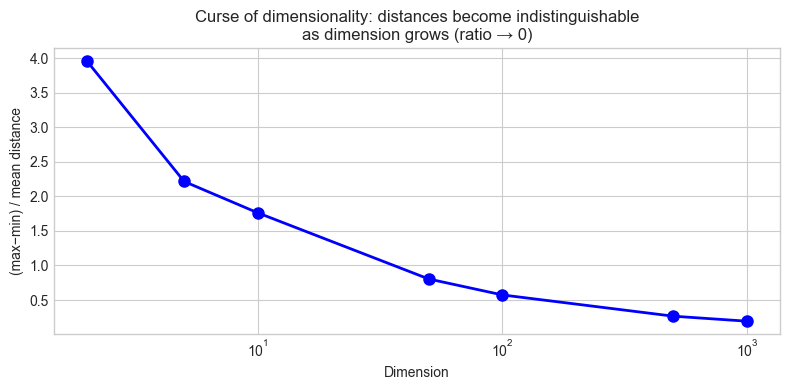

   Dim    (max-min)/mean
     2            3.9596
     5            2.2152
    10            1.7616
    50            0.8043
   100            0.5737
   500            0.2660
  1000            0.1937


In [4]:
# --- Experiment 1: Curse of dimensionality — distances collapse ---
# Hypothesis: In high dimensions, all pairwise distances become similar.
# This is why kNN degrades in high dimensions.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(0)
DIMS = [2, 5, 10, 50, 100, 500, 1000]  # <-- modify
N = 200

ratios = []
for d in DIMS:
    X = rng.standard_normal((N, d))
    # Pairwise distances
    diffs = X[:, None, :] - X[None, :, :]  # (N, N, d)
    dists = np.linalg.norm(diffs, axis=-1)  # (N, N)
    upper = dists[np.triu_indices(N, k=1)]
    ratios.append((upper.max() - upper.min()) / upper.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(DIMS, ratios, 'bo-', lw=2, markersize=8)
ax.set_xlabel('Dimension')
ax.set_ylabel('(max−min) / mean distance')
ax.set_title('Curse of dimensionality: distances become indistinguishable\n'
              'as dimension grows (ratio → 0)')
plt.tight_layout()
plt.show()

print(f"{'Dim':>6}  {'(max-min)/mean':>16}")
for d, r in zip(DIMS, ratios):
    print(f"  {d:4d}  {r:16.4f}")

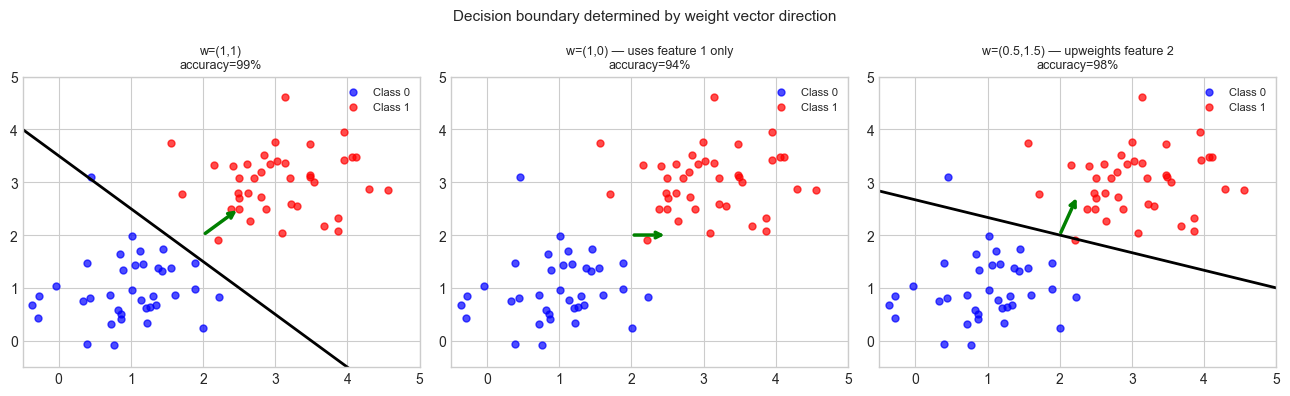

In [5]:
# --- Experiment 2: Decision boundary = dot product threshold ---
# Visualize how different weight vectors create different decision boundaries.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(3)
X = np.vstack([
    rng.multivariate_normal([1,1], 0.4*np.eye(2), 40),
    rng.multivariate_normal([3,3], 0.4*np.eye(2), 40),
])
y = np.array([0]*40 + [1]*40)

weight_vectors = [
    (np.array([1.0, 1.0]), -3.5, 'w=(1,1)'),
    (np.array([1.0, 0.0]), -2.0, 'w=(1,0) — uses feature 1 only'),
    (np.array([0.5, 1.5]), -4.0, 'w=(0.5,1.5) — upweights feature 2'),
]  # <-- modify weights and biases

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
x1_range = np.linspace(-0.5, 5, 100)

for ax, (w, b, title) in zip(axes, weight_vectors):
    ax.scatter(*X[y==0].T, c='blue', s=25, alpha=0.7, label='Class 0')
    ax.scatter(*X[y==1].T, c='red', s=25, alpha=0.7, label='Class 1')

    # Decision boundary: w[0]*x1 + w[1]*x2 + b = 0
    if abs(w[1]) > 1e-9:
        x2_boundary = -(w[0]*x1_range + b) / w[1]
        ax.plot(x1_range, x2_boundary, 'k-', lw=2)

    # Weight vector
    cx, cy = 2.0, 2.0
    ax.annotate('', xy=(cx+w[0]*0.5, cy+w[1]*0.5), xytext=(cx, cy),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))

    preds = np.sign(X @ w + b)
    acc = np.mean(preds == (2*y - 1))
    ax.set_title(f'{title}\naccuracy={acc:.0%}', fontsize=9)
    ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5)
    ax.legend(fontsize=8)

plt.suptitle('Decision boundary determined by weight vector direction', fontsize=11)
plt.tight_layout()
plt.show()

---

## 7. Exercises

**Easy 1.** Given weight vector **w** = (2, −1, 0.5) and bias b = −1, compute the linear model prediction for **x** = (1, 3, 2). Is the prediction positive or negative? What class does it predict?

**Easy 2.** Compute the cosine similarity between **a** = (1, 2, 3) and **b** = (3, 2, 1). Are they similar? What about **a** and **c** = (−1, −2, −3)?

**Medium 1.** Implement a function `document_similarity(doc1_tfidf, doc2_tfidf)` that uses cosine similarity on TF-IDF-like vectors. Generate three synthetic "documents" as sparse vectors and find which pair is most similar.

**Medium 2.** Implement k-NN classification using cosine distance instead of Euclidean distance. On the same 2D synthetic dataset, compare the decision boundaries. When does cosine distance perform better?

**Hard.** Implement logistic regression from scratch using only vector operations: (a) prediction: σ(**w**·**x** + b), (b) binary cross-entropy loss, (c) gradient computation via dot products, (d) gradient descent update. Train it on the 2D synthetic dataset and plot the learning curve and decision boundary.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Vector-Based Recommendation Engine ---
#
# Problem: Represent users and items as vectors. Recommend items
# whose vectors are most similar to a user's preference vector.
# This is the foundation of collaborative filtering.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(0)

# --- Setup: items and users in 3D "taste space" ---
# Dimensions: [action, drama, comedy]
ITEMS = {
    'Die Hard':       np.array([0.95, 0.2, 0.1]),
    'The Notebook':   np.array([0.1, 0.9, 0.3]),
    'Superbad':       np.array([0.1, 0.1, 0.95]),
    'Mad Max':        np.array([0.9, 0.3, 0.05]),
    'Schindlers List':np.array([0.1, 0.95, 0.05]),
    'Anchorman':      np.array([0.05, 0.05, 0.9]),
    'Heat':           np.array([0.85, 0.5, 0.1]),
    'When Harry Met': np.array([0.05, 0.6, 0.8]),
}

# User preference vectors (from their viewing history)
USERS = {
    'Alice':  np.array([0.8, 0.2, 0.1]),   # loves action
    'Bob':    np.array([0.1, 0.1, 0.9]),   # loves comedy
    'Carol':  np.array([0.3, 0.8, 0.4]),   # loves drama + some comedy
}

# Normalize all vectors
def normalize(v):
    return v / (np.linalg.norm(v) + 1e-12)

items_norm = {k: normalize(v) for k, v in ITEMS.items()}
users_norm = {k: normalize(v) for k, v in USERS.items()}

def recommend(user_name, top_k=3):
    """Recommend top-k items for a user using cosine similarity."""
    u = users_norm[user_name]
    scores = {item: float(u @ iv) for item, iv in items_norm.items()}
    ranked = sorted(scores.items(), key=lambda x: -x[1])
    return ranked[:top_k]

print("Recommendations:")
for user in USERS:
    recs = recommend(user)
    print(f"\n{user} (preferences: {USERS[user]}):")
    for item, score in recs:
        print(f"  {item:20s}  similarity = {score:.4f}")

# --- Visualization in 3D taste space ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for name, v in ITEMS.items():
    ax.scatter(*v, c='steelblue', s=80, zorder=5)
    ax.text(v[0]+0.02, v[1]+0.02, v[2]+0.02, name, fontsize=8)

colors = ['red', 'green', 'purple']
for (name, v), c in zip(USERS.items(), colors):
    ax.quiver(0, 0, 0, *v, color=c, lw=2.5, arrow_length_ratio=0.15)
    ax.text(*v*1.05, name, fontsize=10, color=c, fontweight='bold')

ax.set_xlabel('Action'); ax.set_ylabel('Drama'); ax.set_zlabel('Comedy')
ax.set_title('3D Taste Space: items (blue) and user preferences (arrows)')
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What was covered:**
- Data, parameters, and predictions are all vectors; ML operations are vector operations.
- Linear prediction = dot product. The decision boundary is the hyperplane normal to **w**.
- Cosine similarity measures directional alignment — robust to magnitude differences.
- k-NN uses Euclidean distance (vector norms); degrades in high dimensions (curse of dimensionality).
- Embedding arithmetic (word2vec-style) encodes semantic relationships as vector geometry.

**Backward connection:** Every concept in this chapter is a direct application of ch128–134 *(norms, distances, dot products, angles, projections)*. The math was not abstract preparation — it was the exact vocabulary ML uses.

**Forward connections:**
- In ch188 (Linear Layers in Deep Learning), a layer is Xw + b for a batch X — a matrix operation extending the dot product to many samples simultaneously.
- This will reappear in ch185 (PCA Intuition): principal components are the directions that explain maximum variance — eigenvectors of the data covariance matrix.
- In ch295–300 (Part IX capstone), the full ML pipeline — features, model, loss, optimization — is assembled using all the vector tools from this part.